# POACH — Maple Villa Glade Zone

**P**itch · **O**verstory · **A**spect · **C**ontinuity · **H**azard

A terrain-and-canopy model for identifying backcountry glade skiing, validated
against routes mapped by the Granite Backcountry Alliance (GBA). This notebook
walks through the full pipeline for the Maple Villa zone in Intervale, NH.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import ee

from src.terrain import terrain_layers, score_pitch, score_aspect
from src.canopy import fetch_canopy, load_canopy, gap_structure, score_overstory
from src.model import combine, align_to
from src.validation import load_routes, sample_along_routes, plot_overlay

ee.Initialize(project="poach-501022")

## 1. Study area

Maple Villa is a below-treeline hardwood glade on Bartlett Mountain. Its
trailhead sits at the base, with the gladed terrain climbing the slope to the
east. We define the zone from the trailhead and load GBA's mapped routes as
ground truth.

In [2]:
trail_lat, trail_lon = 44.101448, -71.143607
routes = load_routes("../data/validation/maple_villa_route.geojson")
descents = load_routes("../data/validation/maple_villa_descents.geojson")

## 2. Canopy structure (Overstory)

The core of POACH: 1 m NAIP-derived canopy height. Rather than *mean* canopy
cover — which can't distinguish a cut glade from the forest around it — we
compute local **gap structure** (height variability within forest), which
reveals the thinned, skiable corridors that define a glade.

In [3]:
# Fetch canopy over the routes (skips if already downloaded).
route_bbox = gpd.GeoSeries([box(*routes.buffer(250).total_bounds)], crs=5070) \
                .to_crs(4326).total_bounds
canopy_path = "../data/raw/maple_villa_canopy_1m_full.tif"
fetch_canopy(route_bbox, canopy_path, scale=1.0, crs=5070)

canopy = load_canopy(canopy_path)
overstory = score_overstory(gap_structure(canopy, size=15))

Canopy already on disk: ../data/raw/maple_villa_canopy_1m_full.tif


## 3. Terrain (Pitch and Aspect)

Slope steepness and aspect from a 1 m 3DEP DEM, scored for skiability and
snow retention, then aligned onto the canopy grid so all layers combine
pixel-for-pixel.

In [4]:
import py3dep, xrspatial
canopy_bounds = gpd.GeoSeries([box(*canopy.rio.bounds())], crs=canopy.rio.crs) \
                   .to_crs(4326).total_bounds
dem = py3dep.get_dem(tuple(canopy_bounds), resolution=1).rio.reproject(5070)

pitch  = score_pitch(xrspatial.slope(dem)).rio.write_crs(5070)
aspect = score_aspect(xrspatial.aspect(dem)).rio.write_crs(5070)
pitch, aspect = align_to(canopy, pitch, aspect)

/opt/homebrew/Caskroom/miniforge/base/envs/geo/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  ds = xr.merge(
/opt/homebrew/Caskroom/miniforge/base/envs/geo/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  ds = xr.merge(
/opt/homebrew/Caskroom/miniforge/base/

## 4. Combined glade suitability

Pitch and Overstory act as gates (a glade needs both skiable slope and forested
gap structure); Aspect modulates snow quality. The result is a single 0–1
suitability surface.

In [5]:
poach = combine(pitch, aspect, overstory, aspect_weight=0.3)

## 5. Validation against GBA routes

We overlay GBA's mapped routes and compare mean suitability under the routes to
the scene as a whole.

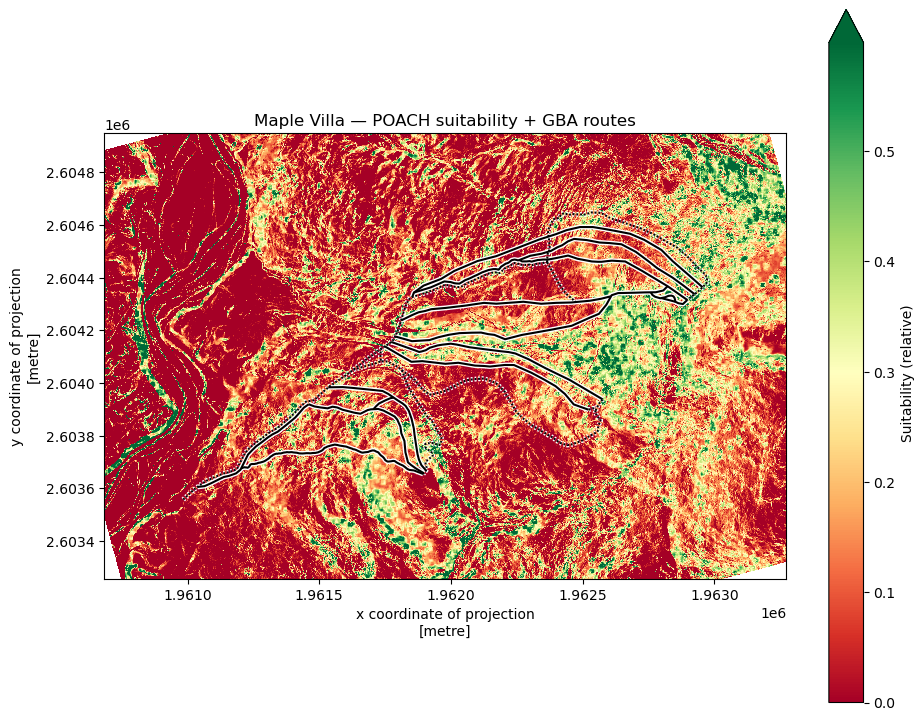

Scene mean:    0.134
All routes:    0.158  (1.2x scene)
Descents only: 0.169  (1.3x scene)


In [6]:
plot_overlay(poach, routes, title="Maple Villa — POACH suitability + GBA routes")
plt.show()

scene_mean = float(poach.values[np.isfinite(poach.values)].mean())
route_mean = sample_along_routes(poach, routes, buffer=15)
descent_mean = sample_along_routes(poach, descents, buffer=15)
print(f"Scene mean:    {scene_mean:.3f}")
print(f"All routes:    {route_mean:.3f}  ({route_mean/scene_mean:.1f}x scene)")
print(f"Descents only: {descent_mean:.3f}  ({descent_mean/scene_mean:.1f}x scene)")